In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
from tensorflow.keras.models import Model
import pandas as pd
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras import backend as keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Recall
from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score
import seaborn as sns

# 繪圖

In [2]:
def plot_CM(true_label, pred_label, title = ' '):
    
    # Creates a confusion matrix
    cm = confusion_matrix(true_label, pred_label) 
    cm[0, 0], cm[1, 1] = cm[1, 1], cm[0, 0]
    # Transform to df for easier plotting
    cm_df = pd.DataFrame(cm,
                         index = ['Positive', 'Negative'], 
                         columns = ['Positive', 'Negative'])

    plt.figure(figsize=(5.5,4))
    sns.heatmap(cm_df, annot=True, fmt="d")

    plt.title(title )
    plt.ylabel('Predicted label')
    plt.xlabel('True label')
    plt.show()

# GPU調整

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
cfg = tf.compat.v1.ConfigProto() 
cfg.gpu_options.visible_device_list="0"
cfg.gpu_options.allow_growth=True
cfg.gpu_options.per_process_gpu_memory_fraction = 0.7# 使用50%的GPU暫存  
session = tf.compat.v1.Session(config=cfg )

In [4]:
def solve_cudnn_error():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.experimental.list_logical_devices('GPU')
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)

In [5]:
solve_cudnn_error()

1 Physical GPUs, 1 Logical GPUs


In [6]:
def train_generator(batch_size, train_path, aug_dict,
        image_color_mode="rgb",
        target_size=(128,128),
        seed=1):
    '''
    can generate image and mask at the same time use the same seed for
    image_datagen and mask_datagen to ensure the transformation for image
    and mask is the same if you want to visualize the results of generator,
    set save_to_dir = "your path"
    '''
    image_datagen = ImageDataGenerator(**aug_dict)
    
    image_generator = image_datagen.flow_from_directory(
        train_path,
        class_mode = "binary",
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        seed = seed)
    for (img, labels) in image_generator:
        yield (img,labels)

In [7]:
def test_generator(batch_size,test_path,
        image_color_mode="rgb",
        target_size=(128,128),
        seed=1):
    test_datagen = ImageDataGenerator(rescale=1./255) 
    
    test_generator = test_datagen.flow_from_directory(
        test_path,
        class_mode = "binary",
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size)
    return test_generator

In [10]:
train_data_folder1 = 'train/gallbladder/'
train_data_folder2="train/another/"
train_files1= [file for file in os.listdir(train_data_folder1) if file.lower().endswith('.jpg')]
train_files2= [file for file in os.listdir(train_data_folder2) if file.lower().endswith('.jpg')]
(len(train_files1), \
 len(train_files2))

(1652, 1548)

## VGG16  沒有驗證集.Dense層1024,512,256,1,Batch_size=8,影像大小128x128

In [13]:
BATCH_SIZE=8
EPOCHS=50
train_generator_args = dict(rescale=1./255,
                            rotation_range=4.5,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            horizontal_flip=True,
                            fill_mode='nearest')

train_gen = train_generator(BATCH_SIZE,
                            "train/",
                            train_generator_args,
                            target_size=(128,128))



In [27]:
base_model = VGG16(weights='imagenet', include_top=False , input_shape=(128,128,3))
# 凍結預訓練模型的層

# 添加自定義的頂層
x = base_model.output
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # num_classes 是你的類別數

model = Model(inputs=base_model.input, outputs=output )

for layer in base_model.layers:
    layer.trainable = False

# 編譯模型
model.compile(optimizer=SGD(lr=0.0001, momentum=0.9), loss='binary_crossentropy', metrics=['accuracy',Recall()])

model.summary()
model_checkpoint = ModelCheckpoint('gallbladder_VGG16.hdf5', 
                                   monitor='loss', 
                                   verbose=1, 
                                   save_best_only=True)

history = model.fit_generator(train_gen,
                              steps_per_epoch=(len(train_files1)+len(train_files2))/ BATCH_SIZE, 
                              epochs=EPOCHS, 
                              callbacks=[model_checkpoint])


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 128, 128, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 128, 128, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 64, 64, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 64, 64, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 64, 64, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 32, 32, 128)       0     

399/400 [============================>.] - ETA: 0s - loss: 0.1518 - accuracy: 0.9386 - recall: 0.9496
Epoch 00016: loss did not improve from 0.14738
400/400 [==============================] - 60s 149ms/step - loss: 0.1524 - accuracy: 0.9381 - recall: 0.9492
Epoch 17/50
399/400 [============================>.] - ETA: 0s - loss: 0.1413 - accuracy: 0.9483 - recall: 0.9575
Epoch 00017: loss improved from 0.14738 to 0.14143, saving model to gallbladder_VGG16.hdf5
400/400 [==============================] - 59s 149ms/step - loss: 0.1414 - accuracy: 0.9484 - recall: 0.9576
Epoch 18/50
399/400 [============================>.] - ETA: 0s - loss: 0.1392 - accuracy: 0.9480 - recall: 0.9593
Epoch 00018: loss improved from 0.14143 to 0.13939, saving model to gallbladder_VGG16.hdf5
400/400 [==============================] - 59s 148ms/step - loss: 0.1394 - accuracy: 0.9478 - recall: 0.9588
Epoch 19/50
399/400 [============================>.] - ETA: 0s - loss: 0.1327 - accuracy: 0.9511 - recall: 0.9624


400/400 [==============================] - 59s 149ms/step - loss: 0.0873 - accuracy: 0.9709 - recall: 0.9740
Epoch 45/50
399/400 [============================>.] - ETA: 0s - loss: 0.0969 - accuracy: 0.9652 - recall: 0.9715
Epoch 00045: loss did not improve from 0.08734
400/400 [==============================] - 60s 150ms/step - loss: 0.0974 - accuracy: 0.9650 - recall: 0.9715
Epoch 46/50
399/400 [============================>.] - ETA: 0s - loss: 0.0856 - accuracy: 0.9680 - recall: 0.9776
Epoch 00046: loss improved from 0.08734 to 0.08592, saving model to gallbladder_VGG16.hdf5
400/400 [==============================] - 60s 149ms/step - loss: 0.0859 - accuracy: 0.9678 - recall: 0.9770
Epoch 47/50
399/400 [============================>.] - ETA: 0s - loss: 0.0994 - accuracy: 0.9630 - recall: 0.9696
Epoch 00047: loss did not improve from 0.08592
400/400 [==============================] - 59s 148ms/step - loss: 0.0993 - accuracy: 0.9631 - recall: 0.9697
Epoch 48/50
399/400 [================

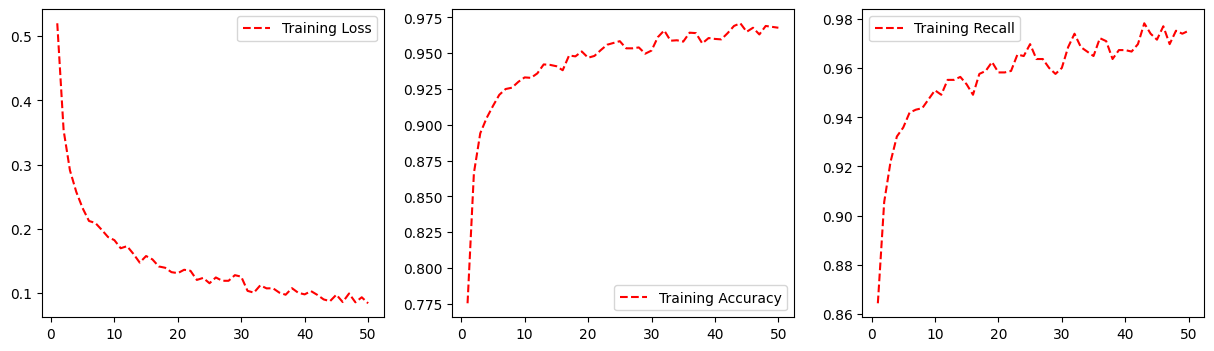

In [30]:
fig, axs = plt.subplots(1, 3, figsize = (15, 4))

training_loss = history.history['loss']

training_accuracy = history.history['accuracy']
training_recall = history.history['recall']
epoch_count = range(1, len(training_loss) + 1)

axs[0].plot(epoch_count, training_loss, 'r--')
axs[0].legend(['Training Loss'])

axs[1].plot(epoch_count, training_accuracy, 'r--')
axs[1].legend(['Training Accuracy'])

axs[2].plot(epoch_count, training_recall, 'r--')
axs[2].legend(['Training Recall'])

In [8]:
model = load_model('gallbladder_VGG16_1.hdf5', compile=True)

In [9]:
def test_predict_load_image(test_file, target_size=(128,128)):
    img = cv2.imread(test_file, cv2.IMREAD_COLOR)
    img = img / 255
    img = cv2.resize(img, target_size)

    img = np.reshape(img,(1,) + img.shape)
    return img

In [10]:
def test_predict_generator(test_files, test_data_folder,target_size=(128,128)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_predict_load_image(test_file, target_size)

In [18]:
test_list=["case1","case2","case3","case4","test"]
for test in test_list:
    test_gen = test_generator(BATCH_SIZE,
                            "test/{}/test".format(test),
                            target_size=(128,128))
    a = model.evaluate(test_gen)
    print(test+"測試結果:", a)

Found 114 images belonging to 2 classes.
15/15 [==============================] - 1s 78ms/step - loss: 0.2204 - accuracy: 0.8860 - recall: 1.0000
case1測試結果: [0.2204122122998039, 0.88596493, 1.0]
Found 107 images belonging to 2 classes.
14/14 [==============================] - 2s 153ms/step - loss: 0.1617 - accuracy: 0.9252 - recall: 0.8571
case2測試結果: [0.16167411853218386, 0.92523366, 0.85714287]
Found 113 images belonging to 2 classes.
15/15 [==============================] - 2s 142ms/step - loss: 0.3354 - accuracy: 0.9204 - recall: 1.0000
case3測試結果: [0.3353687172134717, 0.920354, 1.0]
Found 91 images belonging to 2 classes.
12/12 [==============================] - 1s 58ms/step - loss: 0.6601 - accuracy: 0.7473 - recall: 1.0000
case4測試結果: [0.6601370452675231, 0.74725276, 1.0]
Found 4037 images belonging to 2 classes.
505/505 [==============================] - 30s 59ms/step - loss: 0.3705 - accuracy: 0.8789 - recall: 0.9213
test測試結果: [0.3705420590428829, 0.8788704, 0.9212963]


114/114 [==============================] - 1s 13ms/step
case1
true_label
25
26
27
28
29
30
31
32
33
34
35
predicted_true_label
24
27
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
50
51
52
53
54
55
56
57
59
61
62
accuracy: 0.7543859649122807
recall: 0.7272727272727273


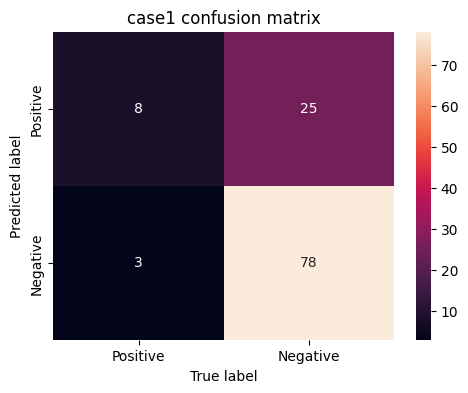

107/107 [==============================] - 1s 11ms/step
case2
true_label
22
23
24
25
26
27
28
predicted_true_label
24
25
26
27
28
29
30
32
33
34
35
36
37
accuracy: 0.9065420560747663
recall: 0.7142857142857143


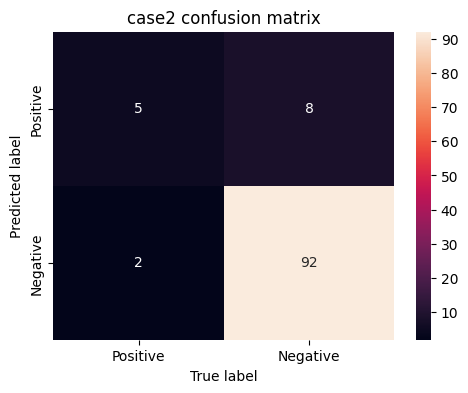

113/113 [==============================] - 1s 11ms/step
case3
true_label
22
23
24
25
26
27
28
29
predicted_true_label
25
27
28
29
30
31
32
33
34
35
36
38
39
40
41
42
43
44
45
46
accuracy: 0.8230088495575221
recall: 0.5


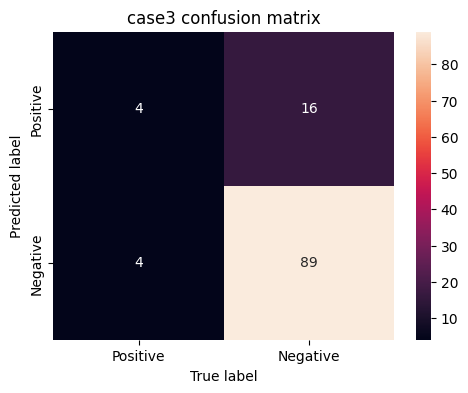

91/91 [==============================] - 1s 11ms/step
case4
true_label
14
15
16
17
18
19
20
21
22
23
24
predicted_true_label
6
7
8
9
10
11
13
14
15
16
17
18
19
20
21
22
24
25
26
27
28
29
30
31
32
33
35
36
37
38
39
41
42
44
accuracy: 0.7252747252747253
recall: 0.9090909090909091


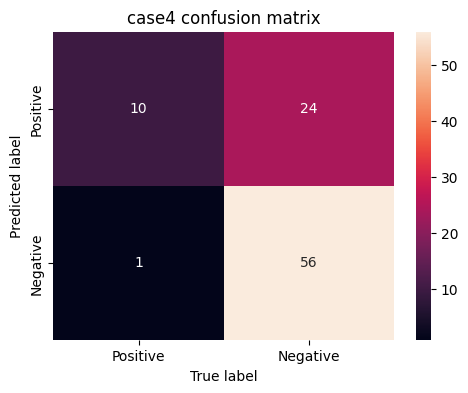

4037/4037 [==============================] - 46s 11ms/step
test
true_label
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
130
131
132
133
134
135
136
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
347
348
349
350
351
352
353
354
355
475
476
477
478
479
480
481
482
483
573
574
575
576
577
578
579
580
581
582
583
584
585
671
672
673
674
675
786
787
788
789
790
791
792
793
794
795
869
870
871
872
873
874
875
876
877
878
976
977
978
979
980
981
982
1084
1085
1086
1087
1088
1089
1090
1091
1092
1093
1094
1095
1096
1097
1098
1190
1191
1192
1193
1194
1195
1196
1197
1198
1199
1200
1201
1202
1203
1204
1205
1301
1302
1303
1304
1305
1414
1415
1416
1417
1418
1419
1420
1421
1516
1517
1518
1519
1520
1521
1522
1523
1524
1525
1526
1527
1528
1529
1530
1531
1532
1533
1534
1535
1536
1537
1609
1610
1611
1612
1613
1614
1615
1616
1617
1618
1619
1620
1708
1709
1710
1711
1712
1713
1714
1715
1716
1717
1815
1816
1817
1818
1819
1820
1821
1822
1823
1824
1921
1922
1923
1924
1925
1926
2039
2040
204

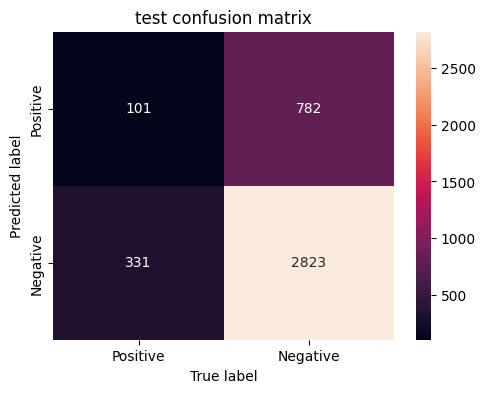

In [20]:
test_list=["case1","case2","case3","case4","test"]
for test in test_list:
    true_classes=[]
    true_label_folder="test/{}/test/gallbladder".format(test)
    true_files=[file for file in os.listdir(true_label_folder) if file.lower().endswith('.jpg')]
    false_label_folder="test/{}/test/another".format(test) 
    false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
    file_num=(len(true_files)+len(false_files)+1)


    
    test_data_folder="test/{}/image".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(128,128))
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    threshold = 0.5  # 可以根据需要调整
    
    # 将预测结果解释为类别
    predicted_classes = [1 if result > threshold else 0 for result in results]
    print(test)
    print("true_label")
    for i in range(1,file_num):
        file_name=str(i)+'.jpg'
        if file_name in true_files:
            print(i)
            true_classes.append(1)
        else:
            true_classes.append(0)
    print("predicted_true_label")
    index=1
    for i in predicted_classes:
        if i==1:
            print(index)
        index=index+1
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("accuracy:",accuracy)
    recall = recall_score(true_classes, predicted_classes )
    print("recall:",recall)
    plot_CM(true_classes, predicted_classes,"{} confusion matrix".format(test))

## VGG16  增加驗證集.Dense層1024,512,1,Batch_size=16 訓練資料不進行翻轉,影像大小256x256

In [11]:
BATCH_SIZE=16
EPOCHS=50
train_generator_args = dict(rescale=1./255,
                            rotation_range=4.5,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            fill_mode='nearest')

train_gen = train_generator(BATCH_SIZE,
                            "train/",
                            train_generator_args,
                            target_size=(256,256))
validation_data =train_generator(BATCH_SIZE,
                            "validation/",
                            train_generator_args,
                            target_size=(256,256))


In [12]:
base_model = VGG16(weights='imagenet', include_top=False , input_shape=(256,256,3))
# 凍結預訓練模型的層

# 添加自定義的頂層
x = base_model.output
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # num_classes 是你的類別數

model = Model(inputs=base_model.input, outputs=output )

for layer in base_model.layers:
    layer.trainable = False

# 編譯模型
model.compile(optimizer=SGD(lr=0.0001, momentum=0.9), loss='binary_crossentropy', metrics=['accuracy',Recall()])

model.summary()
model_checkpoint = ModelCheckpoint('gallbladder_VGG16_2.hdf5', 
                                   monitor='loss', 
                                   verbose=1, 
                                   save_best_only=True)

history = model.fit_generator(train_gen,
                              steps_per_epoch=(len(train_files1)+len(train_files2))/ BATCH_SIZE, 
                              epochs=EPOCHS, 
                              callbacks=[model_checkpoint],
                               validation_data = validation_data,
                              validation_steps =10)


Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 256, 256, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 256, 256, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 256, 256, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 128, 128, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 128, 128, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 128, 128, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 64, 64, 128)       0   

Epoch 36/50
199/200 [============================>.] - ETA: 0s - loss: 0.0515 - accuracy: 0.9868 - recall_1: 0.9909
Epoch 00036: loss did not improve from 0.04957
200/200 [==============================] - 159s 797ms/step - loss: 0.0518 - accuracy: 0.9866 - recall_1: 0.9909 - val_loss: 0.6221 - val_accuracy: 0.8562 - val_recall_1: 1.0000
Epoch 37/50
199/200 [============================>.] - ETA: 0s - loss: 0.0513 - accuracy: 0.9840 - recall_1: 0.9872
Epoch 00037: loss did not improve from 0.04957
200/200 [==============================] - 160s 798ms/step - loss: 0.0517 - accuracy: 0.9837 - recall_1: 0.9867 - val_loss: 0.3696 - val_accuracy: 0.8938 - val_recall_1: 0.9868
Epoch 38/50
199/200 [============================>.] - ETA: 0s - loss: 0.0494 - accuracy: 0.9868 - recall_1: 0.9897
Epoch 00038: loss improved from 0.04957 to 0.04918, saving model to gallbladder_VGG16_2.hdf5
200/200 [==============================] - 160s 801ms/step - loss: 0.0492 - accuracy: 0.9869 - recall_1: 0.9897

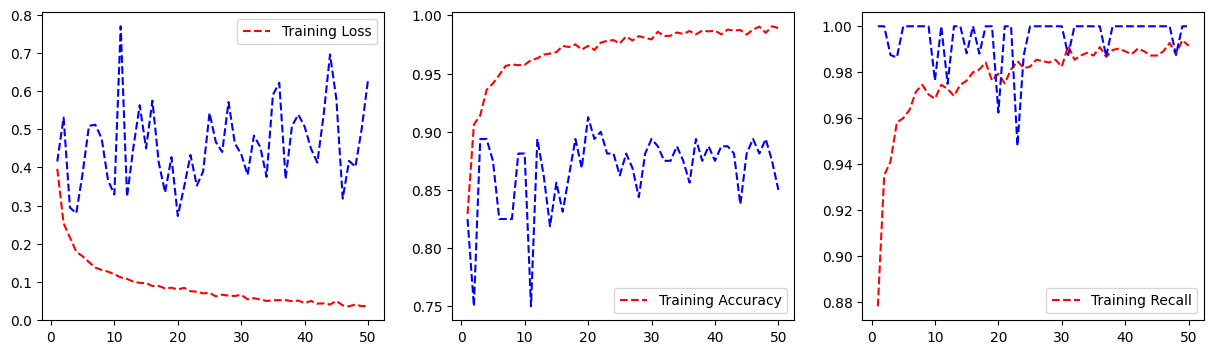

In [15]:
fig, axs = plt.subplots(1, 3, figsize = (15, 4))

training_loss = history.history['loss']
training_accuracy = history.history['accuracy']
training_recall = history.history['recall_1']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']
val_recall = history.history['val_recall_1']
epoch_count = range(1, len(training_loss) + 1)

axs[0].plot(epoch_count, training_loss, 'r--')
axs[0].plot(epoch_count, val_loss, 'b--')
axs[0].legend(['Training Loss'])

axs[1].plot(epoch_count, training_accuracy, 'r--')
axs[1].plot(epoch_count, val_accuracy, 'b--')
axs[1].legend(['Training Accuracy'])

axs[2].plot(epoch_count, training_recall, 'r--')
axs[2].plot(epoch_count, val_recall, 'b--')
axs[2].legend(['Training Recall'])

In [16]:
model = load_model('gallbladder_VGG16_2.hdf5', compile=True)

In [17]:
def test_predict_load_image(test_file, target_size=(256,256)):
    img = cv2.imread(test_file, cv2.IMREAD_COLOR)
    img = img / 255
    img = cv2.resize(img, target_size)

    img = np.reshape(img,(1,) + img.shape)
    return img

In [18]:
def test_predict_generator(test_files, test_data_folder,target_size=(256,256)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_predict_load_image(test_file, target_size)

In [19]:
test_list=["case1","case2","case3","case4","test"]
for test in test_list:
    test_gen = test_generator(16,
                            "test/{}/test".format(test),
                            target_size=(256,256))
    a = model.evaluate(test_gen)
    print(test+"測試結果:", a)

Found 114 images belonging to 2 classes.
8/8 [==============================] - 3s 433ms/step - loss: 0.3908 - accuracy: 0.9123 - recall_1: 1.0000
case1測試結果: [0.390805771574378, 0.9122807, 1.0]
Found 107 images belonging to 2 classes.
7/7 [==============================] - 4s 521ms/step - loss: 0.5629 - accuracy: 0.8037 - recall_1: 1.0000
case2測試結果: [0.5629344774144036, 0.8037383, 1.0]
Found 113 images belonging to 2 classes.
8/8 [==============================] - 3s 333ms/step - loss: 0.3953 - accuracy: 0.8938 - recall_1: 1.0000
case3測試結果: [0.3953315761173144, 0.8938053, 1.0]
Found 91 images belonging to 2 classes.
6/6 [==============================] - 1s 216ms/step - loss: 0.7325 - accuracy: 0.8132 - recall_1: 1.0000
case4測試結果: [0.7324569175640742, 0.8131868, 1.0]
Found 4037 images belonging to 2 classes.
253/253 [==============================] - 60s 238ms/step - loss: 0.4357 - accuracy: 0.8687 - recall_1: 0.9514
test測試結果: [0.43574968464267644, 0.8687144, 0.9513889]


114/114 [==============================] - 3s 25ms/step
case1
true_label
25
[0.90711737]
26
[0.9916169]
27
[0.0357741]
28
[0.9894778]
29
[0.98886263]
30
[0.99534744]
31
[0.9957936]
32
[0.99613637]
33
[0.9996001]
34
[0.9999511]
35
[0.999861]
predicted_true_label
25
26
28
29
30
31
32
33
34
35
36
37
39
40
41
42
43
44
45
accuracy: 0.9122807017543859
recall: 0.9090909090909091


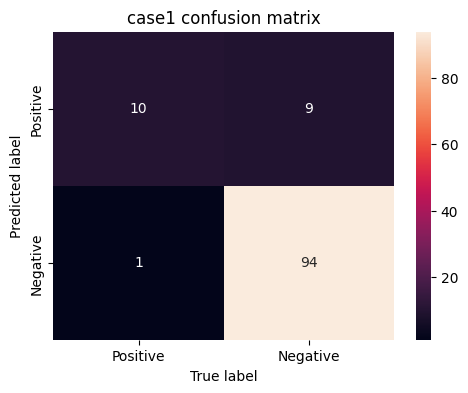

107/107 [==============================] - 2s 23ms/step
case2
true_label
22
[0.2455114]
23
[0.5625545]
24
[0.94322413]
25
[0.99723357]
26
[0.99831295]
27
[0.99916804]
28
[0.9996132]
predicted_true_label
24
25
26
27
28
29
30
32
33
34
35
54
accuracy: 0.9158878504672897
recall: 0.7142857142857143


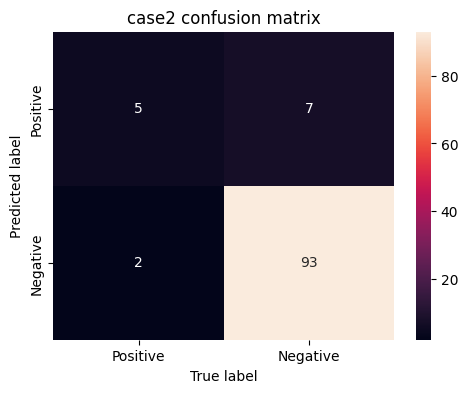

113/113 [==============================] - 3s 23ms/step
case3
true_label
22
[0.07360282]
23
[0.15225919]
24
[0.58568525]
25
[0.90022886]
26
[0.00069814]
27
[0.9865209]
28
[0.9982601]
29
[0.9967135]
predicted_true_label
25
27
28
29
30
31
32
33
34
35
36
38
39
40
41
accuracy: 0.8672566371681416
recall: 0.5


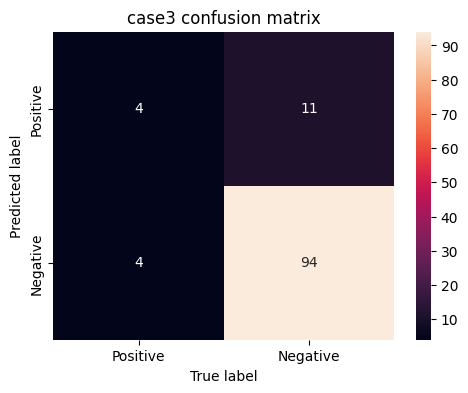

91/91 [==============================] - 2s 23ms/step
case4
true_label
14
[0.9998098]
15
[0.9996382]
16
[0.9991953]
17
[0.99911207]
18
[0.99913883]
19
[0.9983882]
20
[0.99891305]
21
[0.996194]
22
[0.9867813]
23
[5.4519558e-05]
24
[0.99003136]
predicted_true_label
6
7
8
9
10
11
13
14
15
16
17
18
19
20
21
22
24
25
26
27
28
29
31
accuracy: 0.8461538461538461
recall: 0.9090909090909091


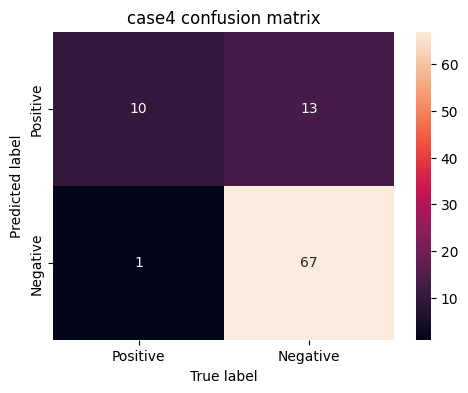

4037/4037 [==============================] - 95s 24ms/step
test
true_label
20
[0.00013652]
21
[8.049902e-05]
22
[9.556959e-06]
23
[6.4135493e-06]
24
[5.7663465e-06]
25
[0.00052812]
26
[3.524266e-06]
27
[2.8596166e-06]
28
[5.5047578e-05]
29
[9.933293e-06]
30
[4.3579807e-06]
31
[2.4438646e-06]
32
[3.0900364e-06]
33
[3.3046258e-06]
34
[1.7746945e-06]
35
[1.0378527e-06]
130
[0.00404312]
131
[0.02598968]
132
[0.09549858]
133
[0.00088086]
134
[0.00013398]
135
[0.0002912]
136
[0.00020151]
241
[0.0214313]
242
[0.05311256]
243
[0.00504474]
244
[0.06312465]
245
[0.07547648]
246
[0.02690927]
247
[0.00369165]
248
[0.00592021]
249
[0.00176185]
250
[0.02603272]
251
[0.03295008]
252
[0.00842803]
253
[0.01765549]
254
[0.0083127]
255
[0.00435173]
256
[0.00462238]
347
[0.998486]
348
[0.9976172]
349
[0.9885338]
350
[0.9960939]
351
[0.9962592]
352
[0.9761727]
353
[0.99329174]
354
[0.99851376]
355
[0.9838324]
475
[0.04800145]
476
[0.03031134]
477
[0.02608967]
478
[0.00425231]
479
[0.00998699]
480
[0.155696

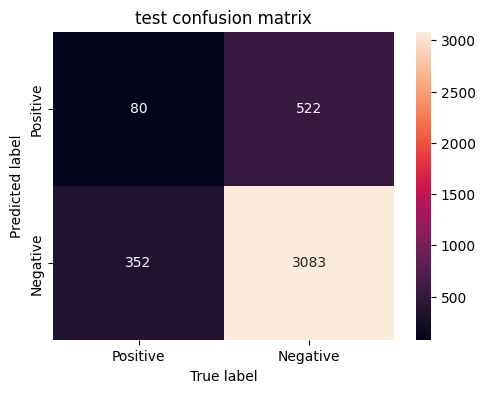

In [26]:
test_list=["case1","case2","case3","case4","test"] #,"case2","case3","case4","test"
for test in test_list:
    true_classes=[]
    true_label_folder="test/{}/test/gallbladder".format(test)
    true_files=[file for file in os.listdir(true_label_folder) if file.lower().endswith('.jpg')]
    false_label_folder="test/{}/test/another".format(test) 
    false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
    file_num=(len(true_files)+len(false_files)+1)


    
    test_data_folder="test/{}/image".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(256,256))
    
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    threshold = 0.9  # 可以根据需要调整
    
    # 将预测结果解释为类别
    predicted_classes = [1 if result > threshold else 0 for result in results]
    print(test)
    print("true_label")
    for i in range(1,file_num):
        file_name=str(i)+'.jpg'
        if file_name in true_files:
            print(i)
            print(results[i-1])
            true_classes.append(1)
        else:
            true_classes.append(0)
    print("predicted_true_label")
    index=1
    for i in predicted_classes:
        if i==1:
            print(index)
        index=index+1
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("accuracy:",accuracy)
    recall = recall_score(true_classes, predicted_classes)
    print("recall:",recall)
    plot_CM(true_classes, predicted_classes,"{} confusion matrix".format(test))

114/114 [==============================] - 3s 26ms/step
case1
true_label
25.jpg
[0.9996001]
26.jpg
[0.9999511]
27.jpg
[0.999861]
28.jpg
[0.9998325]
29.jpg
[0.99982893]
30.jpg
[0.99989164]
31.jpg
[0.99991894]
32.jpg
[0.9992774]
33.jpg
[0.99901175]
34.jpg
[0.99694073]
35.jpg
[0.98370934]
predicted_true_label
18.jpg
19.jpg
20.jpg
21.jpg
22.jpg
23.jpg
24.jpg
25.jpg
26.jpg
27.jpg
28.jpg
29.jpg
30.jpg
31.jpg
32.jpg
33.jpg
34.jpg
35.jpg
36.jpg
37.jpg
accuracy: 0.9210526315789473
recall: 1.0


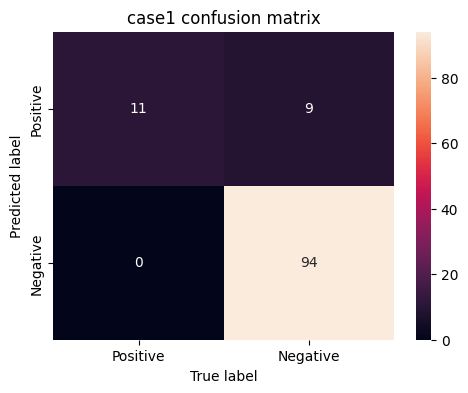

107/107 [==============================] - 2s 23ms/step
case2
true_label
22.jpg
[0.5625545]
23.jpg
[0.94322413]
24.jpg
[0.99723357]
25.jpg
[0.99831295]
26.jpg
[0.99916804]
27.jpg
[0.9996132]
28.jpg
[0.9980844]
predicted_true_label
23.jpg
24.jpg
25.jpg
26.jpg
27.jpg
28.jpg
29.jpg
30.jpg
31.jpg
32.jpg
33.jpg
34.jpg
35.jpg
43.jpg
44.jpg
46.jpg
49.jpg
50.jpg
51.jpg
accuracy: 0.8691588785046729
recall: 0.8571428571428571


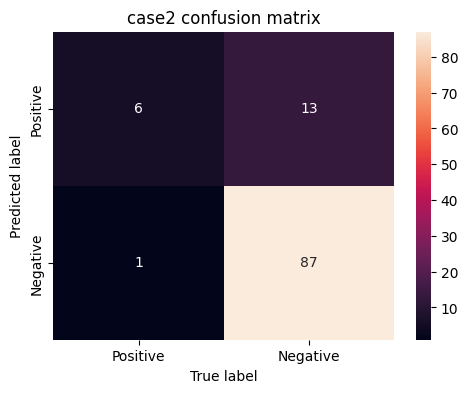

113/113 [==============================] - 3s 23ms/step
case3
true_label
22.jpg
[0.9967135]
23.jpg
[0.9975535]
24.jpg
[0.9995028]
25.jpg
[0.9994259]
26.jpg
[0.9998104]
27.jpg
[0.99990547]
28.jpg
[0.99964726]
29.jpg
[0.99932563]
predicted_true_label
19.jpg
20.jpg
21.jpg
22.jpg
23.jpg
24.jpg
25.jpg
26.jpg
27.jpg
28.jpg
29.jpg
30.jpg
31.jpg
32.jpg
33.jpg
34.jpg
accuracy: 0.9292035398230089
recall: 1.0


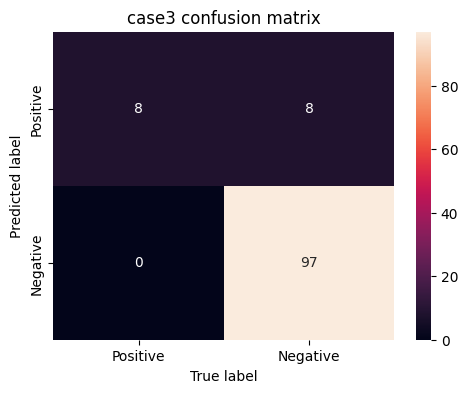

91/91 [==============================] - 2s 23ms/step
case4
true_label
14.jpg
[0.93074137]
15.jpg
[0.99373853]
16.jpg
[0.997053]
17.jpg
[0.99795073]
18.jpg
[0.9972609]
19.jpg
[0.99745995]
20.jpg
[0.9998528]
21.jpg
[0.9998098]
22.jpg
[0.9996382]
23.jpg
[0.9991953]
24.jpg
[0.99911207]
predicted_true_label
14.jpg
15.jpg
16.jpg
17.jpg
18.jpg
19.jpg
20.jpg
21.jpg
22.jpg
23.jpg
24.jpg
25.jpg
26.jpg
27.jpg
28.jpg
29.jpg
30.jpg
31.jpg
32.jpg
33.jpg
34.jpg
35.jpg
37.jpg
40.jpg
41.jpg
accuracy: 0.8461538461538461
recall: 1.0


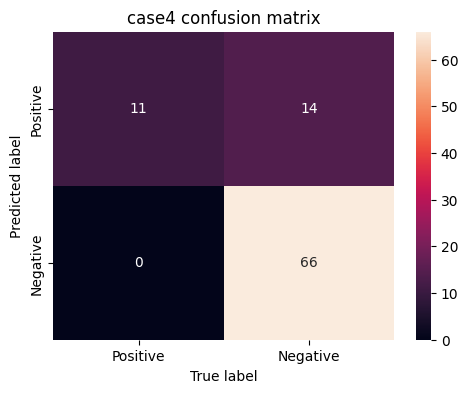

107/107 [==============================] - 2s 23ms/step
case5
true_label
20.jpg
[0.9985644]
21.jpg
[0.9999474]
22.jpg
[0.99996376]
23.jpg
[0.99988973]
24.jpg
[0.99992967]
25.jpg
[0.9998908]
26.jpg
[0.99924374]
27.jpg
[0.9988055]
28.jpg
[0.99564916]
29.jpg
[0.9952579]
30.jpg
[0.98343635]
31.jpg
[0.9924603]
32.jpg
[0.9560484]
33.jpg
[0.9946338]
34.jpg
[0.9627784]
35.jpg
[0.93620086]
predicted_true_label
17.jpg
18.jpg
19.jpg
20.jpg
21.jpg
22.jpg
23.jpg
24.jpg
25.jpg
26.jpg
27.jpg
28.jpg
29.jpg
30.jpg
31.jpg
32.jpg
33.jpg
34.jpg
35.jpg
42.jpg
43.jpg
accuracy: 0.9532710280373832
recall: 1.0


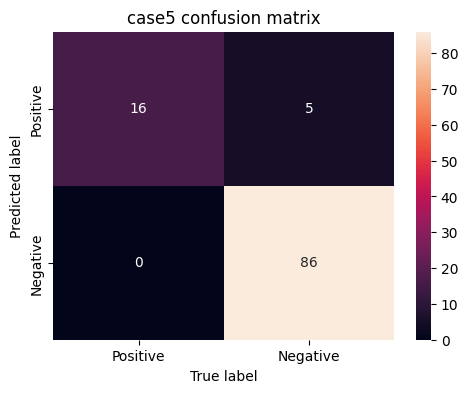

114/114 [==============================] - 3s 23ms/step
case6
true_label
130.jpg
[0.9995203]
131.jpg
[0.998486]
132.jpg
[0.99545646]
133.jpg
[0.9983346]
134.jpg
[0.99686617]
135.jpg
[0.9922118]
136.jpg
[0.96792835]
predicted_true_label
127.jpg
128.jpg
129.jpg
130.jpg
131.jpg
132.jpg
133.jpg
134.jpg
135.jpg
136.jpg
137.jpg
138.jpg
139.jpg
accuracy: 0.9473684210526315
recall: 1.0


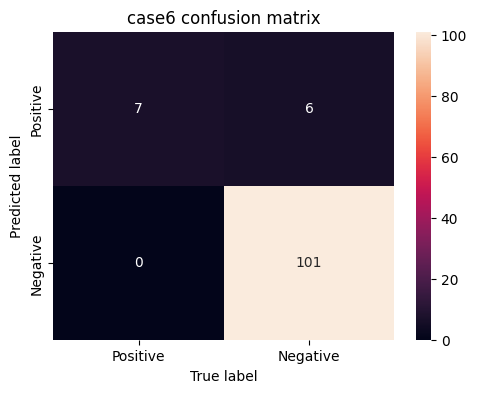

108/108 [==============================] - 3s 24ms/step
case7
true_label
241.jpg
[0.90881085]
242.jpg
[0.99768126]
243.jpg
[0.992943]
244.jpg
[0.9975369]
245.jpg
[0.99556077]
246.jpg
[0.99861264]
247.jpg
[0.99415624]
248.jpg
[0.9954739]
249.jpg
[0.9948407]
250.jpg
[0.9966593]
251.jpg
[0.9617133]
252.jpg
[0.58718055]
253.jpg
[0.22162656]
254.jpg
[0.14189555]
255.jpg
[0.0588397]
256.jpg
[0.395945]
predicted_true_label
240.jpg
241.jpg
242.jpg
243.jpg
244.jpg
245.jpg
246.jpg
247.jpg
248.jpg
249.jpg
250.jpg
251.jpg
accuracy: 0.9444444444444444
recall: 0.6875


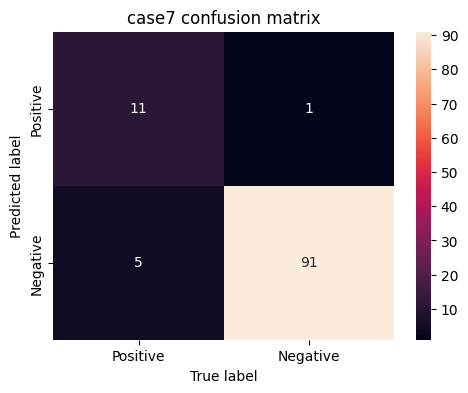

124/124 [==============================] - 3s 24ms/step
case8
true_label
347.jpg
[0.01289819]
348.jpg
[0.06645745]
349.jpg
[0.01147813]
350.jpg
[0.10511106]
351.jpg
[0.71166277]
352.jpg
[0.8690167]
353.jpg
[0.95792055]
354.jpg
[0.9012607]
355.jpg
[0.88106793]
predicted_true_label
352.jpg
353.jpg
354.jpg
355.jpg
356.jpg
357.jpg
358.jpg
359.jpg
360.jpg
361.jpg
362.jpg
363.jpg
364.jpg
372.jpg
accuracy: 0.8790322580645161
recall: 0.4444444444444444


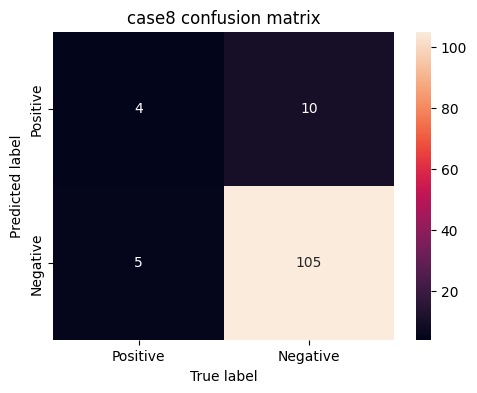

98/98 [==============================] - 2s 24ms/step
case9
true_label
475.jpg
[0.9992168]
476.jpg
[0.9995958]
477.jpg
[0.999368]
478.jpg
[0.9999783]
479.jpg
[0.99991226]
480.jpg
[0.99796695]
481.jpg
[0.9688101]
482.jpg
[0.8837716]
483.jpg
[0.88783896]
predicted_true_label
472.jpg
473.jpg
474.jpg
475.jpg
476.jpg
477.jpg
478.jpg
479.jpg
480.jpg
481.jpg
482.jpg
483.jpg
484.jpg
486.jpg
accuracy: 0.9489795918367347
recall: 1.0


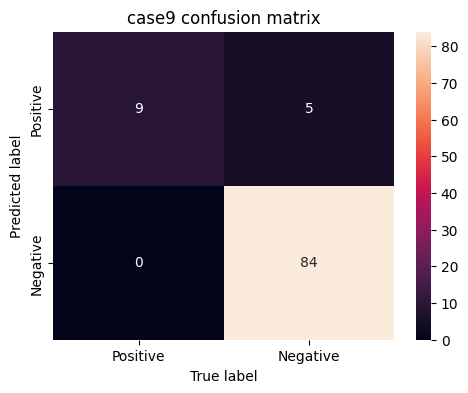

100/100 [==============================] - 2s 24ms/step
case10
true_label
573.jpg
[0.99871504]
574.jpg
[0.9994797]
575.jpg
[0.999874]
576.jpg
[0.9999057]
577.jpg
[0.9999596]
578.jpg
[0.9999515]
579.jpg
[0.99968183]
580.jpg
[0.9995084]
581.jpg
[0.9927347]
582.jpg
[0.9976683]
583.jpg
[0.9761402]
584.jpg
[0.91610473]
585.jpg
[0.91380733]
predicted_true_label
564.jpg
569.jpg
570.jpg
571.jpg
572.jpg
573.jpg
574.jpg
575.jpg
576.jpg
577.jpg
578.jpg
579.jpg
580.jpg
581.jpg
582.jpg
583.jpg
584.jpg
585.jpg
586.jpg
587.jpg
588.jpg
589.jpg
590.jpg
591.jpg
592.jpg
593.jpg
594.jpg
595.jpg
596.jpg
597.jpg
599.jpg
600.jpg
601.jpg
602.jpg
603.jpg
604.jpg
605.jpg
606.jpg
607.jpg
609.jpg
610.jpg
accuracy: 0.72
recall: 1.0


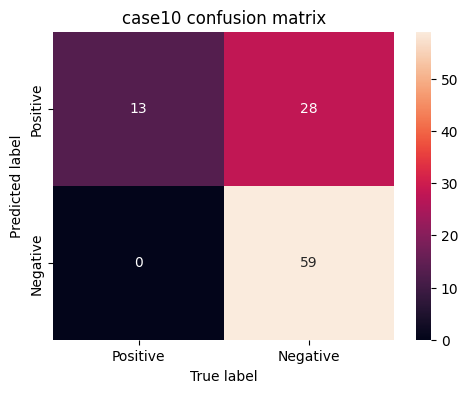

109/109 [==============================] - 3s 24ms/step
case11
true_label
671.jpg
[0.86780274]
672.jpg
[0.80966735]
673.jpg
[0.68594277]
674.jpg
[0.98519844]
675.jpg
[0.9753709]
predicted_true_label
671.jpg
672.jpg
674.jpg
675.jpg
676.jpg
677.jpg
678.jpg
679.jpg
680.jpg
681.jpg
692.jpg
693.jpg
703.jpg
704.jpg
705.jpg
706.jpg
709.jpg
710.jpg
accuracy: 0.8623853211009175
recall: 0.8


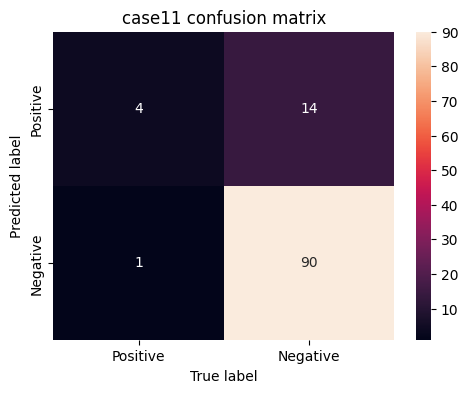

95/95 [==============================] - 2s 24ms/step
case12
true_label
786.jpg
[0.9607873]
787.jpg
[0.98683584]
788.jpg
[0.996443]
789.jpg
[0.9979918]
790.jpg
[0.99469936]
791.jpg
[0.9968123]
792.jpg
[0.9957586]
793.jpg
[0.99668044]
794.jpg
[0.98194075]
795.jpg
[0.87819284]
predicted_true_label
777.jpg
778.jpg
780.jpg
781.jpg
782.jpg
783.jpg
784.jpg
785.jpg
786.jpg
787.jpg
788.jpg
789.jpg
790.jpg
791.jpg
792.jpg
793.jpg
794.jpg
795.jpg
796.jpg
accuracy: 0.9052631578947369
recall: 1.0


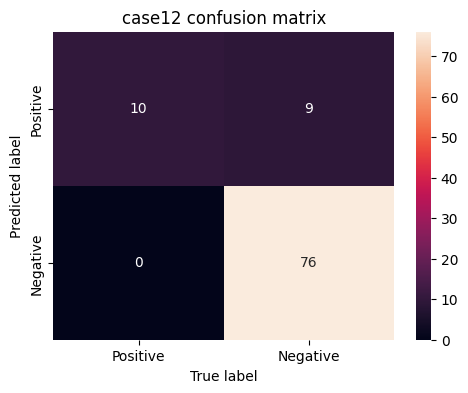

96/96 [==============================] - 2s 24ms/step
case13
true_label
869.jpg
[0.00513774]
870.jpg
[0.18297513]
871.jpg
[0.42899624]
872.jpg
[0.8582144]
873.jpg
[0.90812355]
874.jpg
[0.98735374]
875.jpg
[0.9968316]
876.jpg
[0.9949864]
877.jpg
[0.99332446]
878.jpg
[0.93607926]
predicted_true_label
872.jpg
873.jpg
874.jpg
875.jpg
876.jpg
877.jpg
878.jpg
879.jpg
880.jpg
881.jpg
882.jpg
886.jpg
887.jpg
888.jpg
accuracy: 0.8958333333333334
recall: 0.7


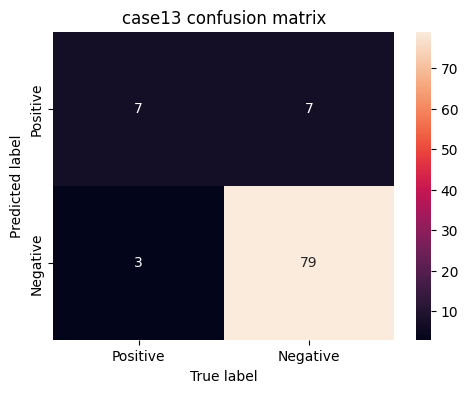

111/111 [==============================] - 3s 24ms/step
case14
true_label
976.jpg
[0.96251625]
977.jpg
[0.99474156]
978.jpg
[0.997903]
979.jpg
[0.9927341]
980.jpg
[0.9917407]
981.jpg
[0.9923659]
982.jpg
[0.9125814]
predicted_true_label
972.jpg
973.jpg
974.jpg
975.jpg
976.jpg
977.jpg
978.jpg
979.jpg
980.jpg
981.jpg
982.jpg
983.jpg
984.jpg
accuracy: 0.9459459459459459
recall: 1.0


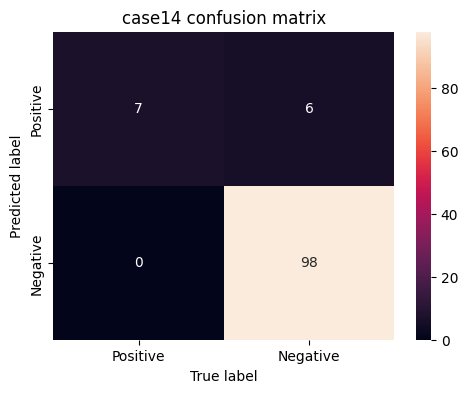

110/110 [==============================] - 3s 24ms/step
case15
true_label
1084.jpg
[0.99972314]
1085.jpg
[0.99988604]
1086.jpg
[0.99997616]
1087.jpg
[0.99960524]
1088.jpg
[0.9997727]
1089.jpg
[0.999782]
1090.jpg
[0.99983597]
1091.jpg
[0.9984654]
1092.jpg
[0.99912256]
1093.jpg
[0.98229676]
1094.jpg
[0.9902408]
1095.jpg
[0.99470973]
1096.jpg
[0.9954412]
1097.jpg
[0.9950004]
1098.jpg
[0.9577599]
predicted_true_label
1078.jpg
1079.jpg
1080.jpg
1081.jpg
1082.jpg
1083.jpg
1084.jpg
1085.jpg
1086.jpg
1087.jpg
1088.jpg
1089.jpg
1090.jpg
1091.jpg
1092.jpg
1093.jpg
1094.jpg
1095.jpg
1096.jpg
1097.jpg
1098.jpg
1099.jpg
accuracy: 0.9363636363636364
recall: 1.0


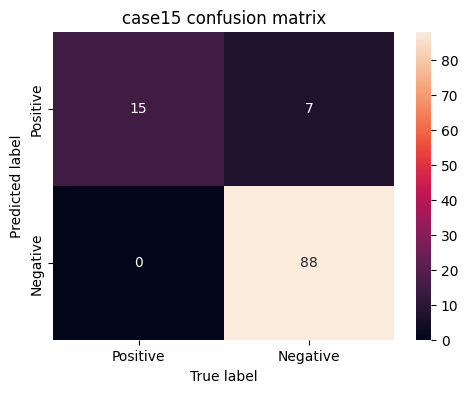

105/105 [==============================] - 3s 24ms/step
case16
true_label
1190.jpg
[0.6517568]
1191.jpg
[0.99865097]
1192.jpg
[0.9995585]
1193.jpg
[0.9998211]
1194.jpg
[0.9980634]
1195.jpg
[0.9927235]
1196.jpg
[0.99867356]
1197.jpg
[0.9793305]
1198.jpg
[0.8824778]
1199.jpg
[0.73411745]
1200.jpg
[0.76596624]
1201.jpg
[0.8659218]
1202.jpg
[0.7652051]
1203.jpg
[0.9521382]
1204.jpg
[0.97648597]
1205.jpg
[0.8812628]
predicted_true_label
1189.jpg
1191.jpg
1192.jpg
1193.jpg
1194.jpg
1195.jpg
1196.jpg
1197.jpg
1198.jpg
1200.jpg
1201.jpg
1202.jpg
1203.jpg
1204.jpg
1205.jpg
accuracy: 0.9714285714285714
recall: 0.875


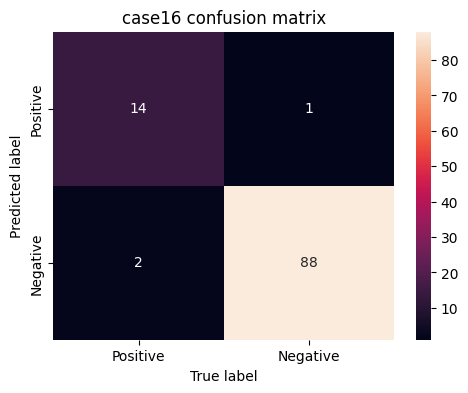

118/118 [==============================] - 3s 24ms/step
case17
true_label
1301.jpg
[0.99945265]
1302.jpg
[0.99971694]
1303.jpg
[0.9998807]
1304.jpg
[0.9998629]
1305.jpg
[0.9998367]
predicted_true_label
1300.jpg
1301.jpg
1302.jpg
1303.jpg
1304.jpg
1305.jpg
1306.jpg
1307.jpg
1308.jpg
1309.jpg
1310.jpg
1311.jpg
1312.jpg
1313.jpg
1314.jpg
1315.jpg
1316.jpg
1317.jpg
1318.jpg
1319.jpg
1320.jpg
1321.jpg
accuracy: 0.8559322033898306
recall: 1.0


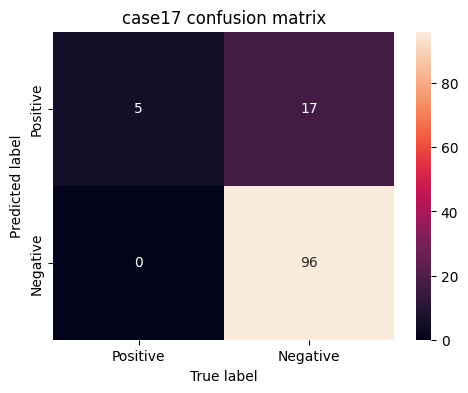

100/100 [==============================] - 2s 24ms/step
case18
true_label
1414.jpg
[0.64390236]
1415.jpg
[0.9105295]
1416.jpg
[0.98543]
1417.jpg
[0.98801243]
1418.jpg
[0.8940975]
1419.jpg
[0.90808463]
1420.jpg
[0.7300497]
1421.jpg
[0.38144258]
predicted_true_label
1415.jpg
1416.jpg
1417.jpg
1418.jpg
1419.jpg
accuracy: 0.97
recall: 0.625


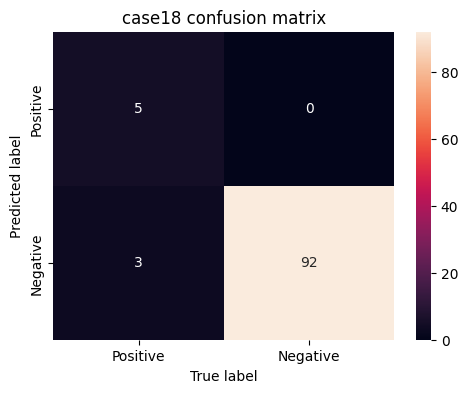

91/91 [==============================] - 2s 24ms/step
case19
true_label
1516.jpg
[0.9901653]
1517.jpg
[0.9909462]
1518.jpg
[0.9974595]
1519.jpg
[0.99642843]
1520.jpg
[0.9986884]
1521.jpg
[0.9969029]
1522.jpg
[0.99356914]
1523.jpg
[0.9962302]
1524.jpg
[0.98477215]
1525.jpg
[0.9938578]
1526.jpg
[0.9982014]
1527.jpg
[0.99800974]
1528.jpg
[0.9787266]
1529.jpg
[0.99283606]
1530.jpg
[0.9872048]
1531.jpg
[0.9968658]
1532.jpg
[0.99235314]
1533.jpg
[0.9886409]
1534.jpg
[0.867018]
1535.jpg
[0.82880354]
1536.jpg
[0.8767132]
1537.jpg
[0.7100468]
predicted_true_label
1514.jpg
1515.jpg
1516.jpg
1517.jpg
1518.jpg
1519.jpg
1520.jpg
1521.jpg
1522.jpg
1523.jpg
1524.jpg
1525.jpg
1526.jpg
1527.jpg
1528.jpg
1529.jpg
1530.jpg
1531.jpg
1532.jpg
1533.jpg
1534.jpg
1535.jpg
1536.jpg
accuracy: 0.967032967032967
recall: 0.9545454545454546


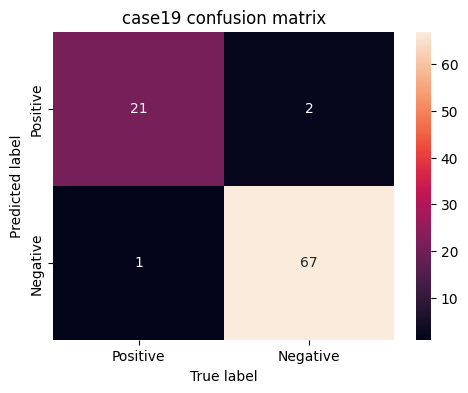

104/104 [==============================] - 2s 24ms/step
case20
true_label
1609.jpg
[0.8692519]
1610.jpg
[0.9481503]
1611.jpg
[0.947931]
1612.jpg
[0.98110193]
1613.jpg
[0.9726599]
1614.jpg
[0.99587786]
1615.jpg
[0.99925023]
1616.jpg
[0.9999573]
1617.jpg
[0.9994802]
1618.jpg
[0.9983669]
1619.jpg
[0.9997074]
1620.jpg
[0.9978054]
predicted_true_label
1608.jpg
1609.jpg
1610.jpg
1611.jpg
1612.jpg
1613.jpg
1614.jpg
1615.jpg
1616.jpg
1617.jpg
1618.jpg
1619.jpg
1620.jpg
1621.jpg
1623.jpg
1624.jpg
1625.jpg
1626.jpg
1627.jpg
1628.jpg
1630.jpg
1633.jpg
1634.jpg
accuracy: 0.8942307692307693
recall: 1.0


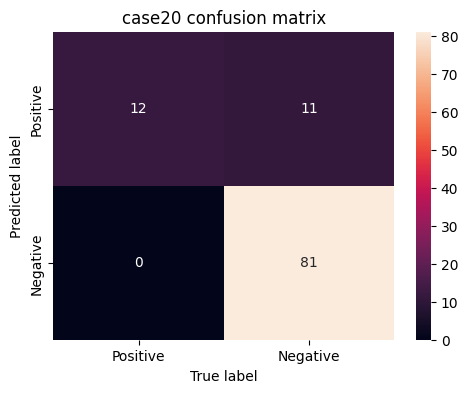

106/106 [==============================] - 3s 24ms/step
case21
true_label
1708.jpg
[0.7775891]
1709.jpg
[0.8676981]
1710.jpg
[0.9674287]
1711.jpg
[0.98858184]
1712.jpg
[0.9977952]
1713.jpg
[0.99979323]
1714.jpg
[0.9995096]
1715.jpg
[0.9990109]
1716.jpg
[0.9998853]
1717.jpg
[0.99984884]
predicted_true_label
1708.jpg
1709.jpg
1710.jpg
1711.jpg
1712.jpg
1713.jpg
1714.jpg
1715.jpg
1716.jpg
1717.jpg
1718.jpg
1719.jpg
1720.jpg
1721.jpg
1722.jpg
1723.jpg
1724.jpg
1726.jpg
accuracy: 0.9245283018867925
recall: 1.0


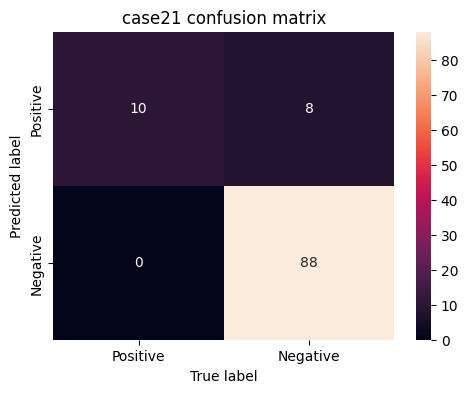

103/103 [==============================] - 2s 24ms/step
case22
true_label
1815.jpg
[0.9337616]
1816.jpg
[0.9952879]
1817.jpg
[0.9945041]
1818.jpg
[0.9891593]
1819.jpg
[0.9577411]
1820.jpg
[0.9890487]
1821.jpg
[0.994429]
1822.jpg
[0.9794724]
1823.jpg
[0.9775509]
1824.jpg
[0.996748]
predicted_true_label
1814.jpg
1815.jpg
1816.jpg
1817.jpg
1818.jpg
1819.jpg
1820.jpg
1821.jpg
1822.jpg
1823.jpg
1824.jpg
1825.jpg
1826.jpg
1827.jpg
1828.jpg
1829.jpg
1830.jpg
1831.jpg
accuracy: 0.9223300970873787
recall: 1.0


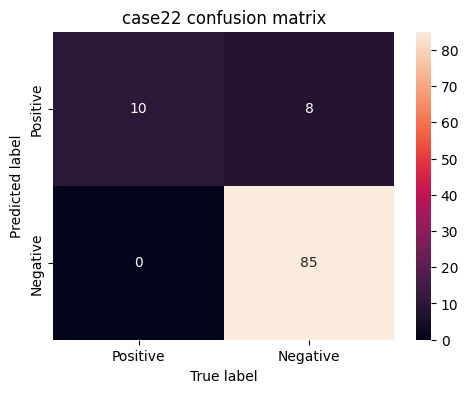

117/117 [==============================] - 3s 24ms/step
case23
true_label
1921.jpg
[0.81839186]
1922.jpg
[0.9890057]
1923.jpg
[0.995216]
1924.jpg
[0.99849284]
1925.jpg
[0.998911]
1926.jpg
[0.9991849]
predicted_true_label
1921.jpg
1922.jpg
1923.jpg
1924.jpg
1925.jpg
1926.jpg
1927.jpg
1928.jpg
1929.jpg
1930.jpg
1931.jpg
1932.jpg
1933.jpg
1934.jpg
1935.jpg
1936.jpg
1937.jpg
1938.jpg
1939.jpg
1940.jpg
1941.jpg
1945.jpg
1946.jpg
1947.jpg
1953.jpg
1967.jpg
accuracy: 0.8290598290598291
recall: 1.0


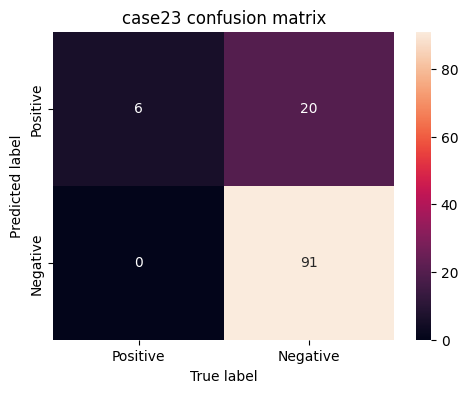

112/112 [==============================] - 3s 24ms/step
case24
true_label
2039.jpg
[0.9821285]
2040.jpg
[0.972378]
2041.jpg
[0.98587507]
2042.jpg
[0.99113184]
2043.jpg
[0.9966719]
2044.jpg
[0.993612]
2045.jpg
[0.99668473]
2046.jpg
[0.9980229]
2047.jpg
[0.9950305]
2048.jpg
[0.99332845]
predicted_true_label
2037.jpg
2038.jpg
2039.jpg
2040.jpg
2041.jpg
2042.jpg
2043.jpg
2044.jpg
2045.jpg
2046.jpg
2047.jpg
2048.jpg
2049.jpg
2050.jpg
accuracy: 0.9642857142857143
recall: 1.0


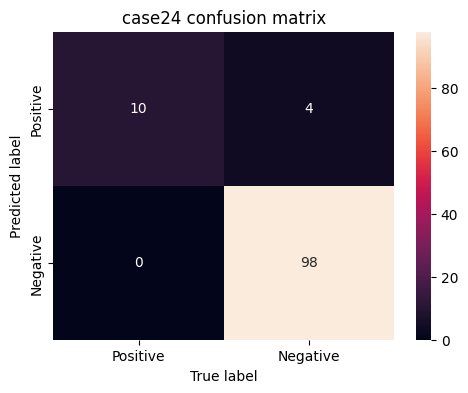

99/99 [==============================] - 2s 24ms/step
case25
true_label
2152.jpg
[0.35916114]
2153.jpg
[0.4138197]
2154.jpg
[0.3965675]
2155.jpg
[0.8683229]
2156.jpg
[0.99031806]
2157.jpg
[0.98570144]
2158.jpg
[0.992669]
2159.jpg
[0.9839153]
2160.jpg
[0.83731186]
predicted_true_label
2149.jpg
2150.jpg
2151.jpg
2155.jpg
2156.jpg
2157.jpg
2158.jpg
2159.jpg
2160.jpg
2161.jpg
accuracy: 0.9292929292929293
recall: 0.6666666666666666


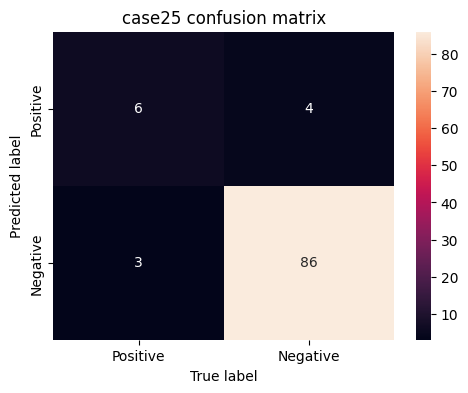

83/83 [==============================] - 2s 24ms/step
case26
true_label
2249.jpg
[0.9533774]
2250.jpg
[0.89651984]
2251.jpg
[0.9407006]
2252.jpg
[0.8831933]
2253.jpg
[0.9281671]
2254.jpg
[0.98244506]
2255.jpg
[0.95551556]
2256.jpg
[0.84014666]
2257.jpg
[0.6900777]
predicted_true_label
2242.jpg
2243.jpg
2244.jpg
2245.jpg
2246.jpg
2247.jpg
2248.jpg
2249.jpg
2250.jpg
2251.jpg
2252.jpg
2253.jpg
2254.jpg
2255.jpg
2256.jpg
2258.jpg
accuracy: 0.891566265060241
recall: 0.8888888888888888


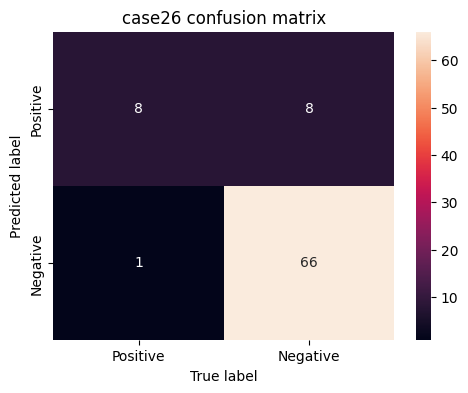

96/96 [==============================] - 2s 24ms/step
case27
true_label
2328.jpg
[0.999949]
2329.jpg
[0.99997604]
2330.jpg
[0.99996483]
2331.jpg
[0.9999021]
2332.jpg
[0.9998258]
2333.jpg
[0.99960357]
predicted_true_label
2322.jpg
2323.jpg
2324.jpg
2325.jpg
2326.jpg
2327.jpg
2328.jpg
2329.jpg
2330.jpg
2331.jpg
2332.jpg
2333.jpg
2334.jpg
2335.jpg
2336.jpg
2337.jpg
2338.jpg
2339.jpg
2340.jpg
2341.jpg
2342.jpg
2343.jpg
2344.jpg
2345.jpg
2346.jpg
2347.jpg
2348.jpg
accuracy: 0.78125
recall: 1.0


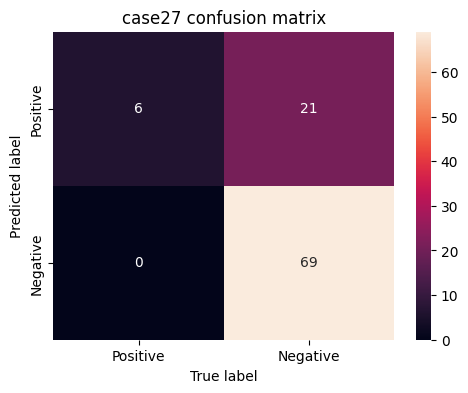

115/115 [==============================] - 3s 24ms/step
case28
true_label
2432.jpg
[0.9993073]
2433.jpg
[0.9996723]
2434.jpg
[0.9994137]
2435.jpg
[0.9992754]
2436.jpg
[0.99963117]
2437.jpg
[0.99966204]
2438.jpg
[0.99746656]
predicted_true_label
2430.jpg
2431.jpg
2432.jpg
2433.jpg
2434.jpg
2435.jpg
2436.jpg
2437.jpg
2438.jpg
2439.jpg
2440.jpg
2441.jpg
2442.jpg
2443.jpg
accuracy: 0.9391304347826087
recall: 1.0


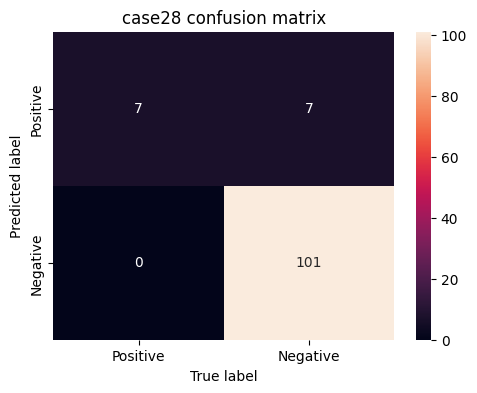

89/89 [==============================] - 2s 24ms/step
case29
true_label
2539.jpg
[0.99975246]
2540.jpg
[0.9998919]
2541.jpg
[0.99989367]
2542.jpg
[0.99998033]
2543.jpg
[0.9999727]
2544.jpg
[0.99976283]
2545.jpg
[0.9998801]
2546.jpg
[0.9993838]
2547.jpg
[0.9994911]
2548.jpg
[0.9994099]
2549.jpg
[0.9994715]
2550.jpg
[0.99946755]
2551.jpg
[0.9980129]
2552.jpg
[0.9833802]
2553.jpg
[0.99405044]
predicted_true_label
2536.jpg
2537.jpg
2538.jpg
2539.jpg
2540.jpg
2541.jpg
2542.jpg
2543.jpg
2544.jpg
2545.jpg
2546.jpg
2547.jpg
2548.jpg
2549.jpg
2550.jpg
2551.jpg
2552.jpg
2553.jpg
2554.jpg
2555.jpg
2556.jpg
accuracy: 0.9325842696629213
recall: 1.0


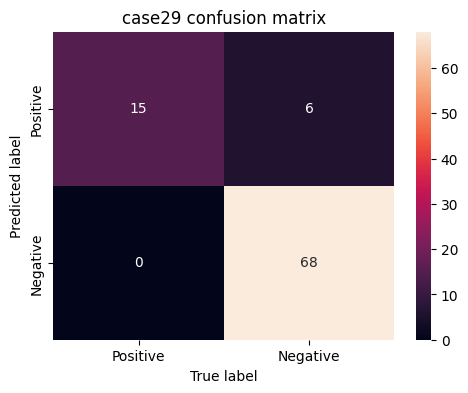

84/84 [==============================] - 2s 24ms/step
case30
true_label
2626.jpg
[0.99921966]
2627.jpg
[0.99990857]
2628.jpg
[0.99996173]
2629.jpg
[0.9999864]
2630.jpg
[0.9999386]
2631.jpg
[0.9999536]
2632.jpg
[0.999974]
2633.jpg
[0.99995065]
2634.jpg
[0.9999018]
2635.jpg
[0.9995654]
2636.jpg
[0.99876595]
2637.jpg
[0.9989261]
2638.jpg
[0.9934122]
2639.jpg
[0.97064126]
2640.jpg
[0.9910425]
predicted_true_label
2622.jpg
2623.jpg
2624.jpg
2625.jpg
2626.jpg
2627.jpg
2628.jpg
2629.jpg
2630.jpg
2631.jpg
2632.jpg
2633.jpg
2634.jpg
2635.jpg
2636.jpg
2637.jpg
2638.jpg
2639.jpg
2640.jpg
2641.jpg
accuracy: 0.9404761904761905
recall: 1.0


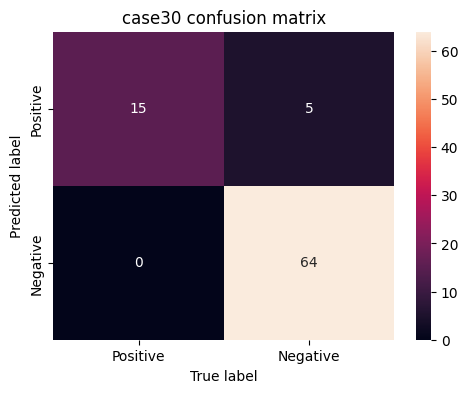

129/129 [==============================] - 3s 24ms/step
case31
true_label
2717.jpg
[0.27562487]
2718.jpg
[0.5841458]
2719.jpg
[0.9549467]
2720.jpg
[0.9953454]
2721.jpg
[0.9955636]
2722.jpg
[0.9989604]
2723.jpg
[0.9992932]
2724.jpg
[0.9995728]
2725.jpg
[0.99992037]
2726.jpg
[0.99944204]
2727.jpg
[0.99991155]
2728.jpg
[0.9999703]
2729.jpg
[0.9998716]
2730.jpg
[0.9997907]
2731.jpg
[0.9995358]
2732.jpg
[0.99964714]
2733.jpg
[0.99985075]
2734.jpg
[0.99909496]
predicted_true_label
2719.jpg
2720.jpg
2721.jpg
2722.jpg
2723.jpg
2724.jpg
2725.jpg
2726.jpg
2727.jpg
2728.jpg
2729.jpg
2730.jpg
2731.jpg
2732.jpg
2733.jpg
2734.jpg
2735.jpg
2736.jpg
2737.jpg
2738.jpg
2739.jpg
2740.jpg
2741.jpg
2742.jpg
2743.jpg
2744.jpg
2745.jpg
2746.jpg
2747.jpg
2748.jpg
2749.jpg
2750.jpg
2752.jpg
2753.jpg
2754.jpg
accuracy: 0.8372093023255814
recall: 0.8888888888888888


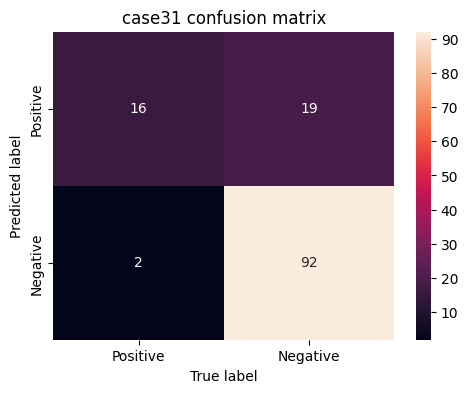

108/108 [==============================] - 3s 24ms/step
case32
true_label
2838.jpg
[0.17001687]
2839.jpg
[0.59186727]
2840.jpg
[0.80398214]
2841.jpg
[0.39370707]
2842.jpg
[0.7870167]
2843.jpg
[0.9568301]
2844.jpg
[0.98605746]
2845.jpg
[0.99674606]
2846.jpg
[0.99829954]
2847.jpg
[0.9976453]
2848.jpg
[0.9988367]
2849.jpg
[0.99869686]
2850.jpg
[0.9984825]
2851.jpg
[0.999616]
2852.jpg
[0.9970592]
2853.jpg
[0.99852544]
2854.jpg
[0.99783105]
2855.jpg
[0.96498966]
2856.jpg
[0.9833655]
2857.jpg
[0.98250765]
2858.jpg
[0.81796145]
2859.jpg
[0.77564096]
2860.jpg
[0.16085808]
2861.jpg
[0.18341278]
2862.jpg
[0.33395436]
2863.jpg
[0.6959017]
2864.jpg
[0.4732879]
2865.jpg
[0.02752476]
2866.jpg
[0.07402673]
predicted_true_label
2840.jpg
2842.jpg
2843.jpg
2844.jpg
2845.jpg
2846.jpg
2847.jpg
2848.jpg
2849.jpg
2850.jpg
2851.jpg
2852.jpg
2853.jpg
2854.jpg
2855.jpg
2856.jpg
2857.jpg
2858.jpg
2859.jpg
accuracy: 0.9074074074074074
recall: 0.6551724137931034


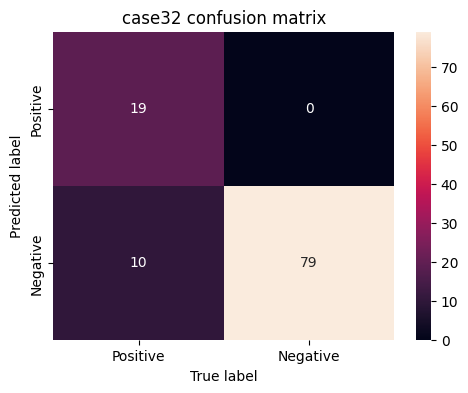

94/94 [==============================] - 2s 24ms/step
case33
true_label
2955.jpg
[0.9993654]
2956.jpg
[0.9987601]
2957.jpg
[0.9989322]
2958.jpg
[0.99837047]
2959.jpg
[0.9994332]
2960.jpg
[0.9994825]
2961.jpg
[0.99775475]
2962.jpg
[0.98902565]
2963.jpg
[0.8987549]
2964.jpg
[0.84768206]
2965.jpg
[0.72156376]
2966.jpg
[0.4154771]
2967.jpg
[0.5724294]
predicted_true_label
2946.jpg
2949.jpg
2950.jpg
2951.jpg
2952.jpg
2953.jpg
2954.jpg
2955.jpg
2956.jpg
2957.jpg
2958.jpg
2959.jpg
2960.jpg
2961.jpg
2962.jpg
2963.jpg
2964.jpg
accuracy: 0.8936170212765957
recall: 0.7692307692307693


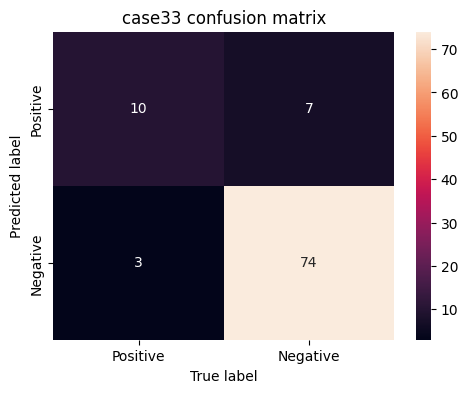

93/93 [==============================] - 2s 24ms/step
case34
true_label
3050.jpg
[0.99919397]
3051.jpg
[0.9946666]
3052.jpg
[0.98885125]
3053.jpg
[0.99734586]
3054.jpg
[0.9974632]
3055.jpg
[0.99876946]
3056.jpg
[0.9980438]
3057.jpg
[0.99801886]
predicted_true_label
3046.jpg
3047.jpg
3048.jpg
3049.jpg
3050.jpg
3051.jpg
3052.jpg
3053.jpg
3054.jpg
3055.jpg
3056.jpg
3057.jpg
3058.jpg
3059.jpg
3060.jpg
3061.jpg
3062.jpg
accuracy: 0.9032258064516129
recall: 1.0


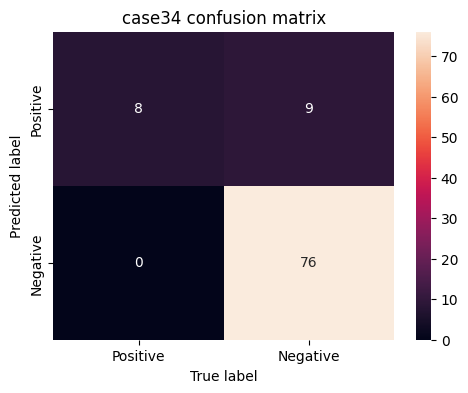

111/111 [==============================] - 3s 24ms/step
case35
true_label
3143.jpg
[0.9952727]
3144.jpg
[0.9846362]
3145.jpg
[0.9864117]
3146.jpg
[0.9970902]
3147.jpg
[0.99935836]
3148.jpg
[0.99985504]
3149.jpg
[0.99926895]
3150.jpg
[0.99863607]
3151.jpg
[0.99109685]
3152.jpg
[0.9625681]
predicted_true_label
3140.jpg
3141.jpg
3142.jpg
3143.jpg
3144.jpg
3145.jpg
3146.jpg
3147.jpg
3148.jpg
3149.jpg
3150.jpg
3151.jpg
3152.jpg
3153.jpg
accuracy: 0.963963963963964
recall: 1.0


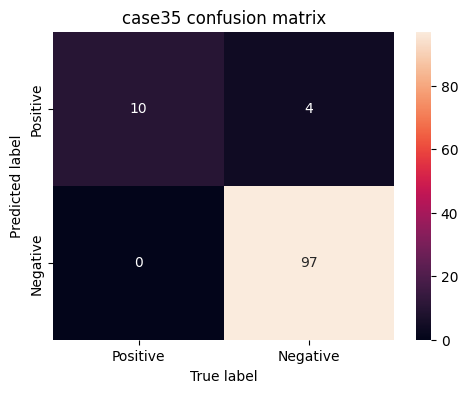

108/108 [==============================] - 3s 24ms/step
case36
true_label
3248.jpg
[0.92379373]
3249.jpg
[0.97673917]
3250.jpg
[0.94025224]
3251.jpg
[0.9781607]
3252.jpg
[0.99274725]
3253.jpg
[0.999665]
3254.jpg
[0.99929416]
3255.jpg
[0.9974515]
3256.jpg
[0.9969805]
predicted_true_label
3246.jpg
3247.jpg
3248.jpg
3249.jpg
3250.jpg
3251.jpg
3252.jpg
3253.jpg
3254.jpg
3255.jpg
3256.jpg
3257.jpg
3258.jpg
3260.jpg
3261.jpg
accuracy: 0.9444444444444444
recall: 1.0


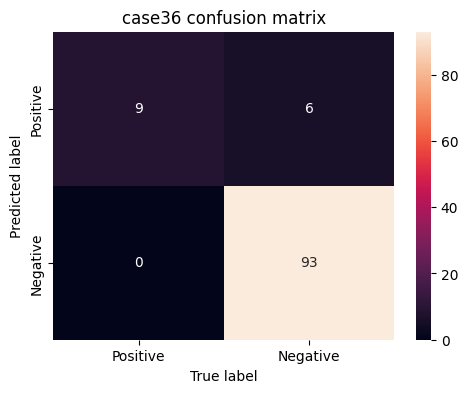

87/87 [==============================] - 2s 24ms/step
case37
true_label
3353.jpg
[0.72484]
3354.jpg
[0.94560283]
3355.jpg
[0.97860503]
3356.jpg
[0.9981565]
3357.jpg
[0.9998267]
3358.jpg
[0.9996183]
3359.jpg
[0.9996673]
3360.jpg
[0.9992428]
3361.jpg
[0.99970263]
3362.jpg
[0.9997236]
3363.jpg
[0.99975497]
3364.jpg
[0.9989755]
predicted_true_label
3354.jpg
3355.jpg
3356.jpg
3357.jpg
3358.jpg
3359.jpg
3360.jpg
3361.jpg
3362.jpg
3363.jpg
3364.jpg
3365.jpg
3366.jpg
3367.jpg
3368.jpg
accuracy: 0.9425287356321839
recall: 0.9166666666666666


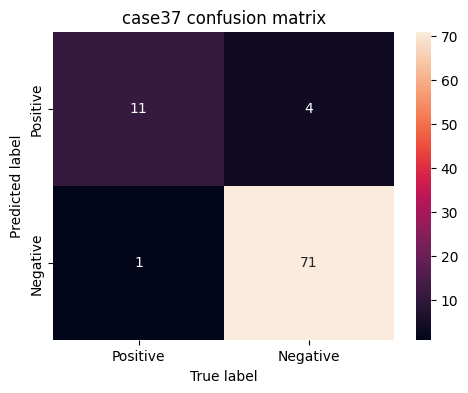

101/101 [==============================] - 2s 24ms/step
case38
true_label
3443.jpg
[0.5139034]
3444.jpg
[0.86005664]
3445.jpg
[0.8819445]
3446.jpg
[0.94426143]
3447.jpg
[0.9510091]
3448.jpg
[0.9834425]
3449.jpg
[0.99129105]
3450.jpg
[0.9976412]
predicted_true_label
3444.jpg
3445.jpg
3446.jpg
3447.jpg
3448.jpg
3449.jpg
3450.jpg
3451.jpg
3452.jpg
3453.jpg
3454.jpg
3455.jpg
3456.jpg
3457.jpg
3458.jpg
3460.jpg
accuracy: 0.900990099009901
recall: 0.875


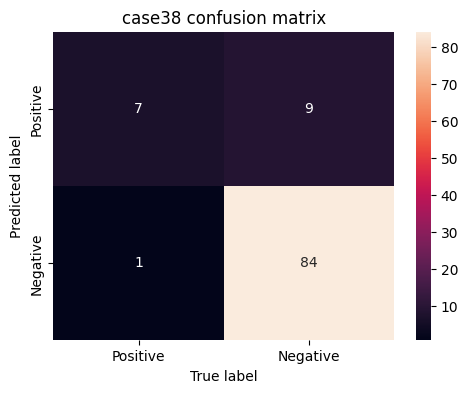

87/87 [==============================] - 2s 24ms/step
case39
true_label
3548.jpg
[0.9997557]
3549.jpg
[0.99943894]
3550.jpg
[0.9947635]
3551.jpg
[0.9968016]
3552.jpg
[0.99875355]
3553.jpg
[0.9993349]
3554.jpg
[0.9979892]
3555.jpg
[0.99705243]
3556.jpg
[0.9867523]
3557.jpg
[0.986347]
3558.jpg
[0.99062717]
predicted_true_label
3544.jpg
3545.jpg
3546.jpg
3547.jpg
3548.jpg
3549.jpg
3550.jpg
3551.jpg
3552.jpg
3553.jpg
3554.jpg
3555.jpg
3556.jpg
3557.jpg
3558.jpg
3559.jpg
3560.jpg
3561.jpg
3562.jpg
3563.jpg
3564.jpg
3565.jpg
accuracy: 0.8735632183908046
recall: 1.0


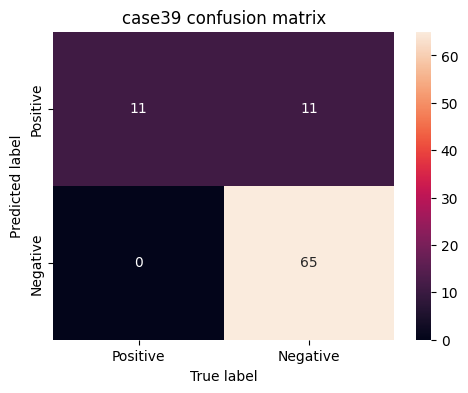

all_test
all_accuracy: 0.9071092395343077
all_recall: 0.9027777777777778


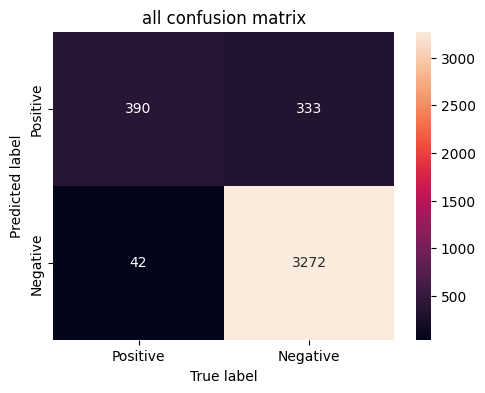

In [40]:

test_list=[] #,"case2","case3","case4","test"
for case in range(1,40):
    test_list.append("case"+str(case))
all_true_classes=[]
all_predicted_classes=[]
for test in test_list:
    true_classes=[]
    true_label_folder="test/{}/test/gallbladder".format(test)
    true_files=[file for file in os.listdir(true_label_folder) if file.lower().endswith('.jpg')]
    false_label_folder="test/{}/test/another".format(test) 
    false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
    file_num=(len(true_files)+len(false_files)+1)


    
    test_data_folder="test/{}/image".format(test)
    
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(256,256))
    
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    threshold = 0.75  # 可以根据需要调整
    
    # 将预测结果解释为类别 
    predicted_classes = [1 if result > threshold else 0 for result in results]
    print(test)
    print("true_label")
    for i in range(1,file_num):
        file_name=test_files[i-1]
        if file_name in true_files:
            print(file_name)
            print(results[i-1])
            true_classes.append(1)
        else:
            true_classes.append(0)
    print("predicted_true_label")
    index=1
    for i in predicted_classes:
        if i==1:
            print(test_files[index-1])
        index=index+1
    all_true_classes=all_true_classes+true_classes
    all_predicted_classes=all_predicted_classes+predicted_classes
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("accuracy:",accuracy)
    recall = recall_score(true_classes, predicted_classes)
    print("recall:",recall)
    plot_CM(true_classes, predicted_classes,"{} confusion matrix".format(test))
print("all_test")
accuracy = accuracy_score(all_true_classes, all_predicted_classes)
print("all_accuracy:",accuracy)
recall = recall_score(all_true_classes, all_predicted_classes)
print("all_recall:",recall)
plot_CM(all_true_classes, all_predicted_classes,"all confusion matrix")

# 無history

114/114 [==============================] - 3s 27ms/step
case1
true_label
25
26
27
28
29
30
31
32
33
34
35
predicted_true_label
1
13
19
20
21
22
23
24
25
26
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
55
56
58
62
63
65
66
67
68
69
70
72
73
74
87
88
97
106
107
accuracy: 0.5964912280701754
recall: 0.9090909090909091


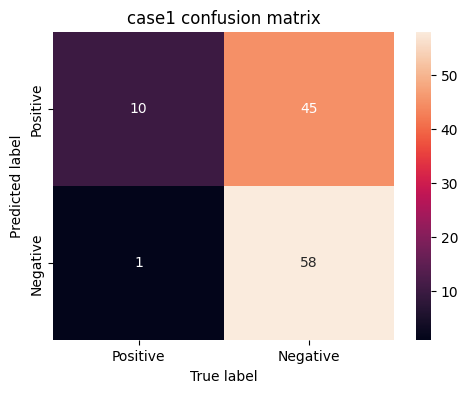

107/107 [==============================] - 3s 24ms/step
case2
true_label
22
23
24
25
26
27
28
predicted_true_label
22
23
24
25
26
27
28
29
30
32
33
34
35
36
37
38
39
40
41
43
44
45
46
47
48
49
50
51
52
54
55
56
57
58
59
60
61
62
63
66
67
68
accuracy: 0.6728971962616822
recall: 1.0


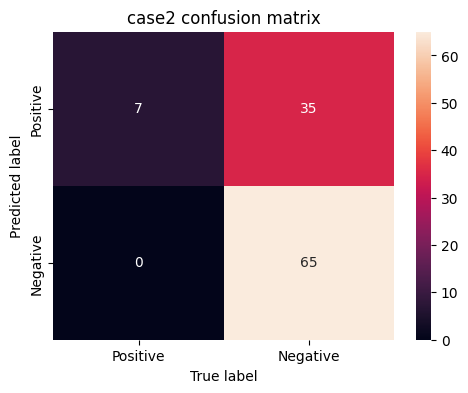

113/113 [==============================] - 3s 24ms/step
case3
true_label
22
23
24
25
26
27
28
29
predicted_true_label
22
23
24
25
27
28
29
30
31
32
33
34
35
36
38
39
40
41
42
43
44
45
46
47
49
50
51
52
53
54
55
56
57
58
60
accuracy: 0.7433628318584071
recall: 0.875


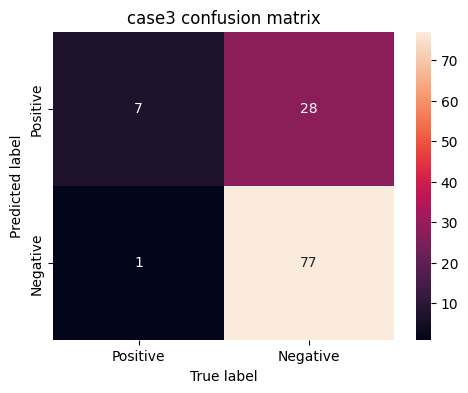

91/91 [==============================] - 2s 24ms/step
case4
true_label
14
15
16
17
18
19
20
21
22
23
24
predicted_true_label
2
3
4
5
6
7
8
9
10
11
13
14
15
16
17
18
19
20
21
22
24
25
26
27
28
29
30
31
32
33
35
36
37
38
39
40
44
47
accuracy: 0.6813186813186813
recall: 0.9090909090909091


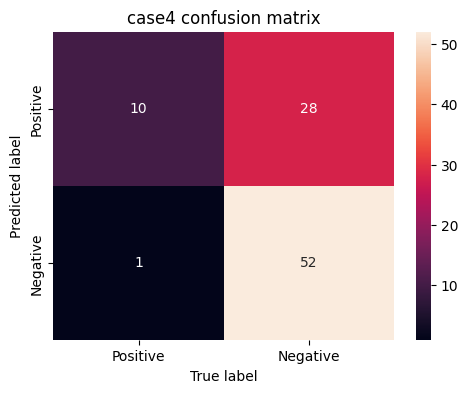

4037/4037 [==============================] - 98s 24ms/step
test
true_label
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
130
131
132
133
134
135
136
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
347
348
349
350
351
352
353
354
355
475
476
477
478
479
480
481
482
483
573
574
575
576
577
578
579
580
581
582
583
584
585
671
672
673
674
675
786
787
788
789
790
791
792
793
794
795
869
870
871
872
873
874
875
876
877
878
976
977
978
979
980
981
982
1084
1085
1086
1087
1088
1089
1090
1091
1092
1093
1094
1095
1096
1097
1098
1190
1191
1192
1193
1194
1195
1196
1197
1198
1199
1200
1201
1202
1203
1204
1205
1301
1302
1303
1304
1305
1414
1415
1416
1417
1418
1419
1420
1421
1516
1517
1518
1519
1520
1521
1522
1523
1524
1525
1526
1527
1528
1529
1530
1531
1532
1533
1534
1535
1536
1537
1609
1610
1611
1612
1613
1614
1615
1616
1617
1618
1619
1620
1708
1709
1710
1711
1712
1713
1714
1715
1716
1717
1815
1816
1817
1818
1819
1820
1821
1822
1823
1824
1921
1922
1923
1924
1925
1926
2039
2040
204

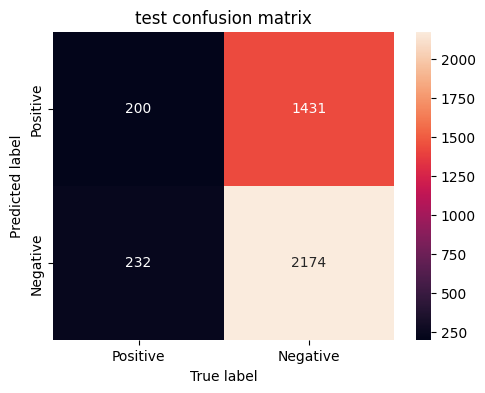

In [39]:
test_list=["case1","case2","case3","case4","test"]
for test in test_list:
    true_classes=[]
    true_label_folder="test/{}/test/gallbladder".format(test)
    true_files=[file for file in os.listdir(true_label_folder) if file.lower().endswith('.jpg')]
    false_label_folder="test/{}/test/another".format(test) 
    false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
    file_num=(len(true_files)+len(false_files)+1)


    
    test_data_folder="test/{}/image".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_predict_gen = test_predict_generator(test_files, test_data_folder,target_size=(256,256))
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    threshold = 0.05  # 可以根据需要调整
    
    # 将预测结果解释为类别
    predicted_classes = [1 if result > threshold else 0 for result in results]
    print(test)
    print("true_label")
    for i in range(1,file_num):
        file_name=str(i)+'.jpg'
        if file_name in true_files:
            print(i)
            true_classes.append(1)
        else:
            true_classes.append(0)
    print("predicted_true_label")
    index=1
    for i in predicted_classes:
        if i==1:
            print(index)
        index=index+1
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("accuracy:",accuracy)
    recall = recall_score(true_classes, predicted_classes)
    print("recall:",recall)
    plot_CM(true_classes, predicted_classes,"{} confusion matrix".format(test))

In [33]:
test_list=["case1","case2","case3","case4","test"]
for test in test_list:
    test_gen = test_generator(16,
                            "test/{}/test".format(test),
                            target_size=(256,256))
    a = model.evaluate(test_gen)
    print(test+"測試結果:", a)

Found 114 images belonging to 2 classes.
8/8 [==============================] - 6s 712ms/step - loss: 0.4254 - accuracy: 0.9035 - recall: 1.0000
case1測試結果: [0.42537274584174156, 0.9035088, 1.0]
Found 107 images belonging to 2 classes.
7/7 [==============================] - 4s 521ms/step - loss: 0.6673 - accuracy: 0.7757 - recall: 1.0000
case2測試結果: [0.6673135182687214, 0.7757009, 1.0]
Found 113 images belonging to 2 classes.
8/8 [==============================] - 3s 313ms/step - loss: 0.4456 - accuracy: 0.8584 - recall: 1.0000
case3測試結果: [0.44562483438130585, 0.8584071, 1.0]
Found 91 images belonging to 2 classes.
6/6 [==============================] - 1s 216ms/step - loss: 0.8796 - accuracy: 0.7802 - recall: 1.0000
case4測試結果: [0.8796212477609515, 0.7802198, 1.0]
Found 4037 images belonging to 2 classes.
253/253 [==============================] - 57s 226ms/step - loss: 0.5429 - accuracy: 0.8397 - recall: 0.9676
test測試結果: [0.5428938316880715, 0.83973247, 0.9675926]


# Unet分割2次

In [16]:
def test_load_image(test_file, target_size=(256,256)):
    img = cv2.imread(test_file, cv2.IMREAD_GRAYSCALE)
    img = img / 255
    img = cv2.resize(img, target_size)
    img = np.reshape(img, img.shape + (1,))
    img = np.reshape(img,(1,) + img.shape)
    return img

def test_generator(test_files,test_data_folder , target_size=(256,256)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_load_image(test_file, target_size)
        
def save_result(save_path, npyfile, test_files):
    for i, item in enumerate(npyfile):
        result_file = test_files[i]
        img = (item[:, :, 0] * 255.).astype(np.uint8)

        filename, fileext = os.path.splitext(os.path.basename(result_file))

        result_file = os.path.join(save_path, "%s_predict%s" % (filename, fileext))

        cv2.imwrite(result_file, img)

In [17]:
model = load_model('unet8_gallbladder_seg.hdf5', compile=False)

In [18]:
test_list=[] #,"case2","case3","case4","test"
for case in range(1,40):
    test_list.append("case"+str(case))
for test in test_list:
    test_data_folder="test/{}/gal_image".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_gen = test_generator(test_files,test_data_folder ,target_size=(512,512))
    results = model.predict_generator(test_gen, len(test_files), verbose=1)
    save_result("test/{}/image_mask".format(test), results, test_files)

15/15 [==============================] - 1s 51ms/step


In [3]:
for test in test_list:
    img_dir="test/{}/gal_image".format(test)
    mask_dir="test/{}/unet10_output".format(test)
    output_dir="test/{}/unet10_image".format(test)
    img_files=[file for file in os.listdir(img_dir) if file.lower().endswith('.jpg')]
    mask_files=[file for file in os.listdir(mask_dir) if file.lower().endswith('.jpg')]
    for i in range(0,len(img_files)):
        original_im=cv2.imread(os.path.join(img_dir,img_files[i]))
        mask_im=cv2.imread(os.path.join(mask_dir,mask_files[i]))
        result = np.zeros_like(original_im)
        result[mask_im > 50] = original_im[mask_im > 50]
        cv2.imwrite(os.path.join(output_dir,img_files[i]),result)

In [28]:
model1 = load_model('unet10_gallbladder_seg.hdf5', compile=False)

In [29]:
test_list=[] #,"case2","case3","case4","test"
for case in range(1,40):
    test_list.append("case"+str(case))
for test in test_list:
    test_data_folder="test/{}/unet10_input".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_gen = test_generator(test_files,test_data_folder ,target_size=(512,512))
    results = model1.predict_generator(test_gen, len(test_files), verbose=1)
    save_result("test/{}/unet10_output".format(test), results, test_files)

15/15 [==============================] - 1s 51ms/step


In [ ]:
for test in test_list:
    img_dir="test/{}/gal_image".format(test)
    mask_dir="test/{}/image_mask".format(test)
    output_dir="test/{}/unet10_input".format(test)
    img_files=[file for file in os.listdir(img_dir) if file.lower().endswith('.jpg')]
    mask_files=[file for file in os.listdir(mask_dir) if file.lower().endswith('.jpg')]
    for i in range(0,len(img_files)):
        original_im=cv2.imread(os.path.join(img_dir,img_files[i]))
        mask_im=cv2.imread(os.path.join(mask_dir,mask_files[i]))
        result = np.zeros_like(original_im)
        result[mask_im > 50] = original_im[mask_im > 50]
        cv2.imwrite(os.path.join(output_dir,img_files[i]),result)

In [23]:
model2 = load_model('unet12_gallbladder_seg.hdf5', compile=False)

In [24]:
test_list=[] #,"case2","case3","case4","test"
for case in range(1,40):
    test_list.append("case"+str(case))
for test in test_list:
    test_data_folder="test/{}/image_mask".format(test)
    test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
    test_gen = test_generator(test_files,test_data_folder ,target_size=(512,512))
    results = model2.predict_generator(test_gen, len(test_files), verbose=1)
    save_result("test/{}/mask2".format(test), results, test_files)

15/15 [==============================] - 1s 51ms/step
